In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy
import re

# List of result files to visualize
types = ['standard', 'noisy', 'probabilistic', 'prob_noisy']
dfs = []
normalized_r_summs = []

def extract_base_name(name):
    # Remove anything after ':' or '(' or '[' (for meta strategies and parameterized names)
    return re.split(r'[:\(\[]', name)[0].strip()

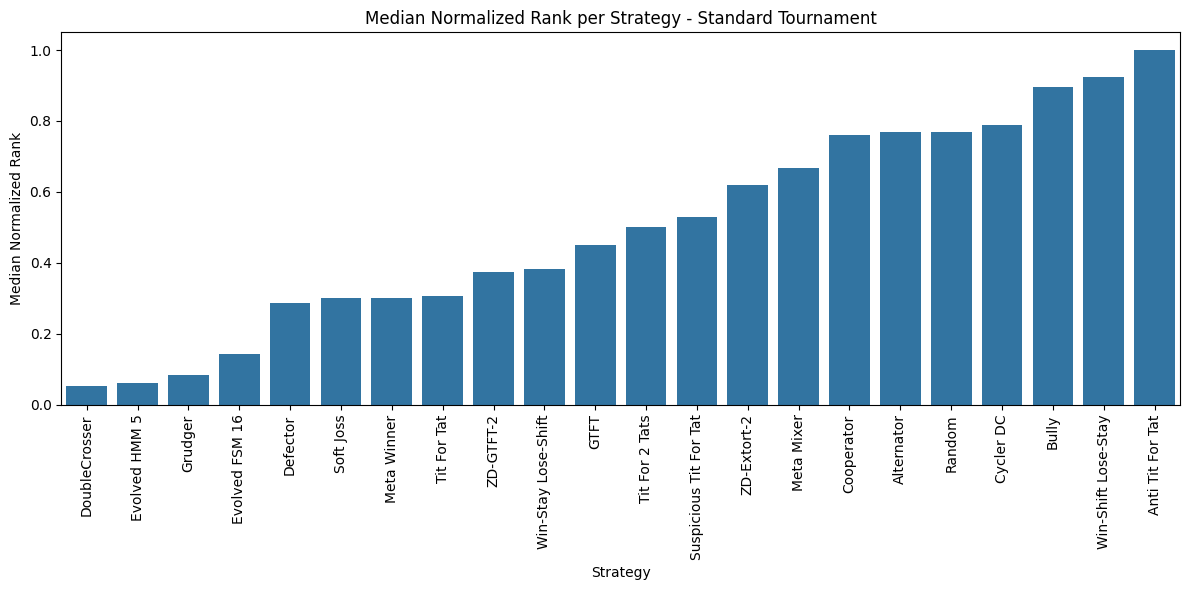

Saved plot: graphs/standard_median_normalized_ranks.png


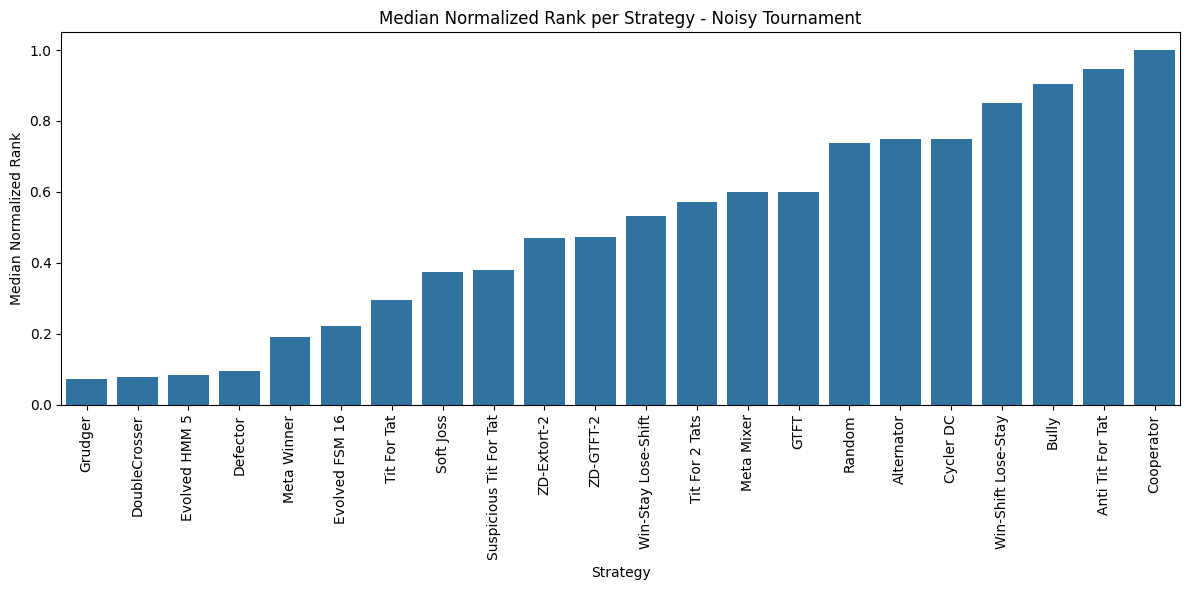

Saved plot: graphs/noisy_median_normalized_ranks.png


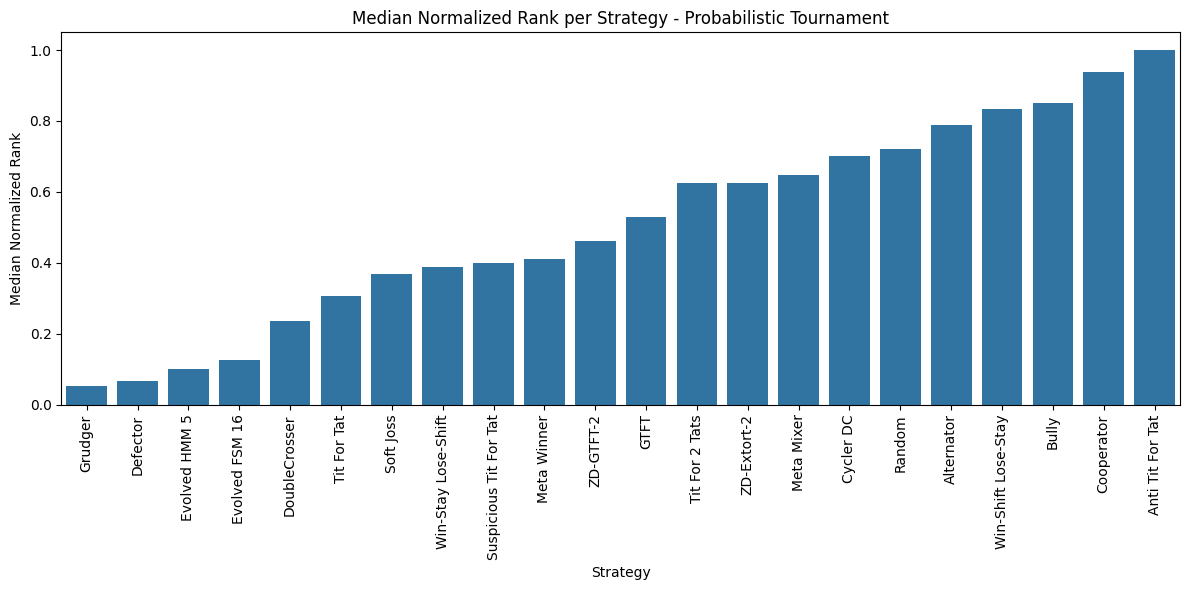

Saved plot: graphs/probabilistic_median_normalized_ranks.png


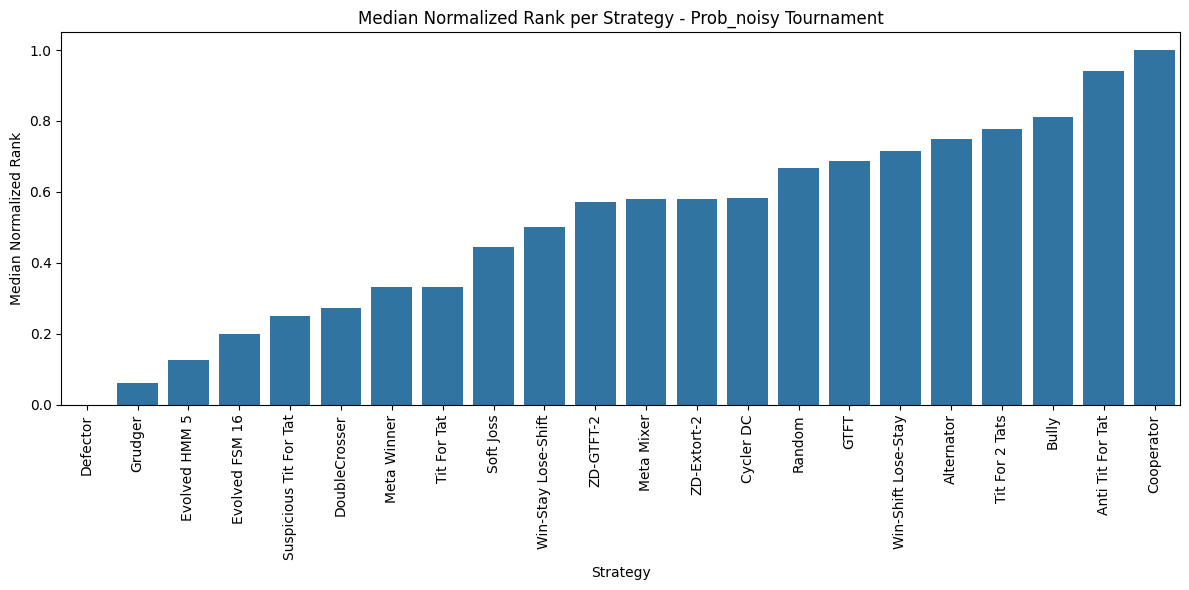

Saved plot: graphs/prob_noisy_median_normalized_ranks.png


In [49]:
for t in types:
    filename = os.path.join("csv", f"{t}_aggregated.csv")
    if not os.path.exists(filename):
        print(f"File {filename} not found, skipping.")
        continue
    df = pd.read_csv(filename)
    df['tournament_type'] = t
    df['BaseName'] = df['Name'].apply(extract_base_name)

    # Calculate normalized ranks
    df['normalized_rank'] = df['Rank'] / (df['n_strategies'] - 1)
    
    dfs.append(df)
    # Plot average score per strategy (original barplot)
    if 'BaseName' in df.columns and 'normalized_rank' in df.columns:
        plt.figure(figsize=(12, 6))
        # Group by BaseName only, averaging across all runs/conditions for this tournament type
        avg_scores = df.groupby('BaseName')['normalized_rank'].median().sort_values()
        sns.barplot(x=avg_scores.index, y=avg_scores.values)
        plt.title(f"Median Normalized Rank per Strategy - {t.capitalize()} Tournament")
        plt.ylabel("Median Normalized Rank")
        plt.xlabel("Strategy")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        plt.savefig(f"graphs/{t}_median_normalized_ranks.png")
        plt.close()
        print(f"Saved plot: graphs/{t}_median_normalized_ranks.png")
    else:
        print(f"'BaseName' or 'normalized_rank' column not found in {filename}, skipping plot.")


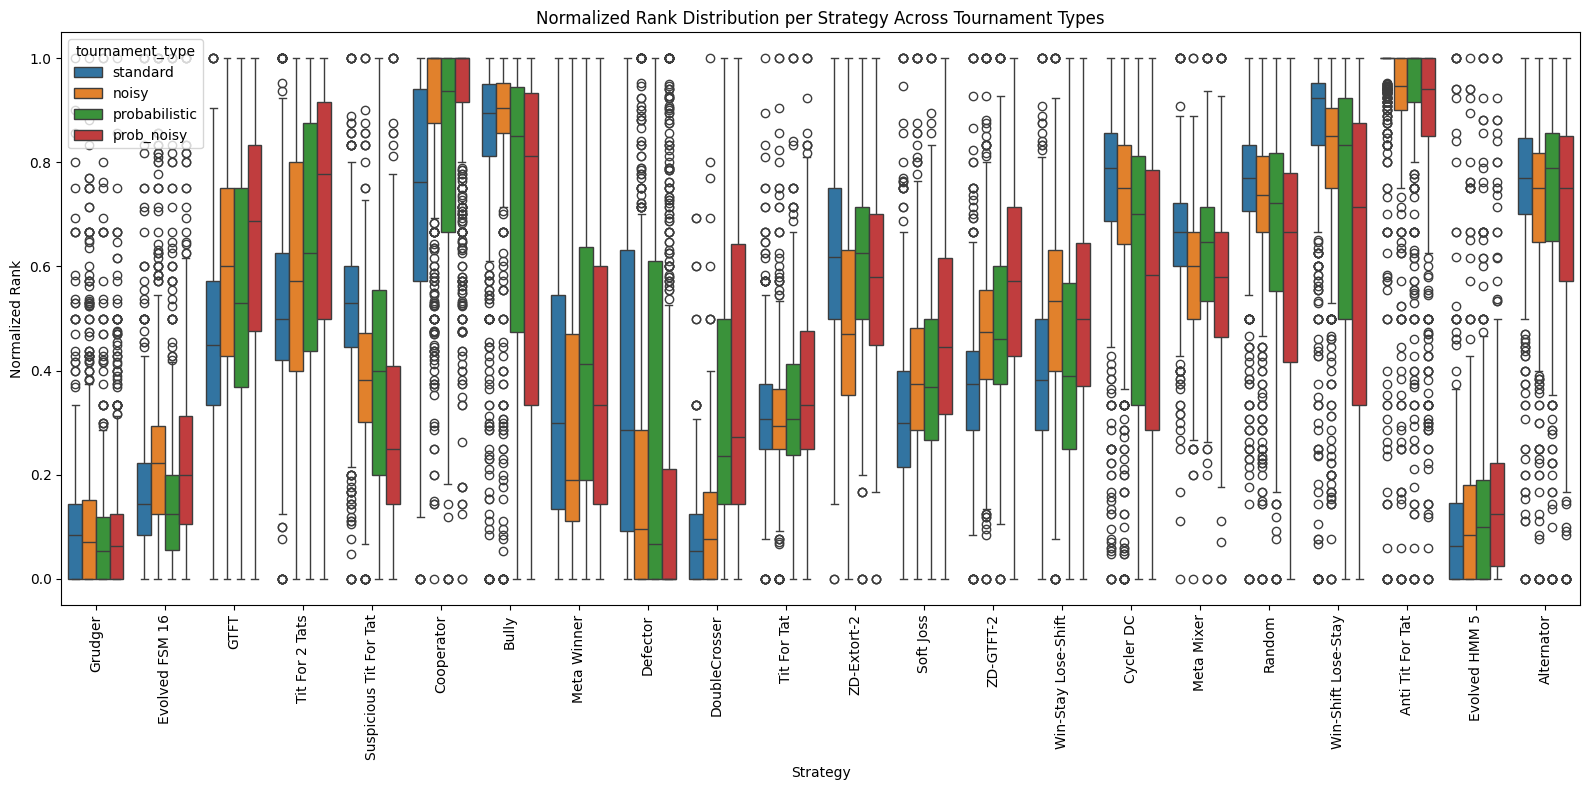

Saved plot: graphs/score_distribution_boxplot.png


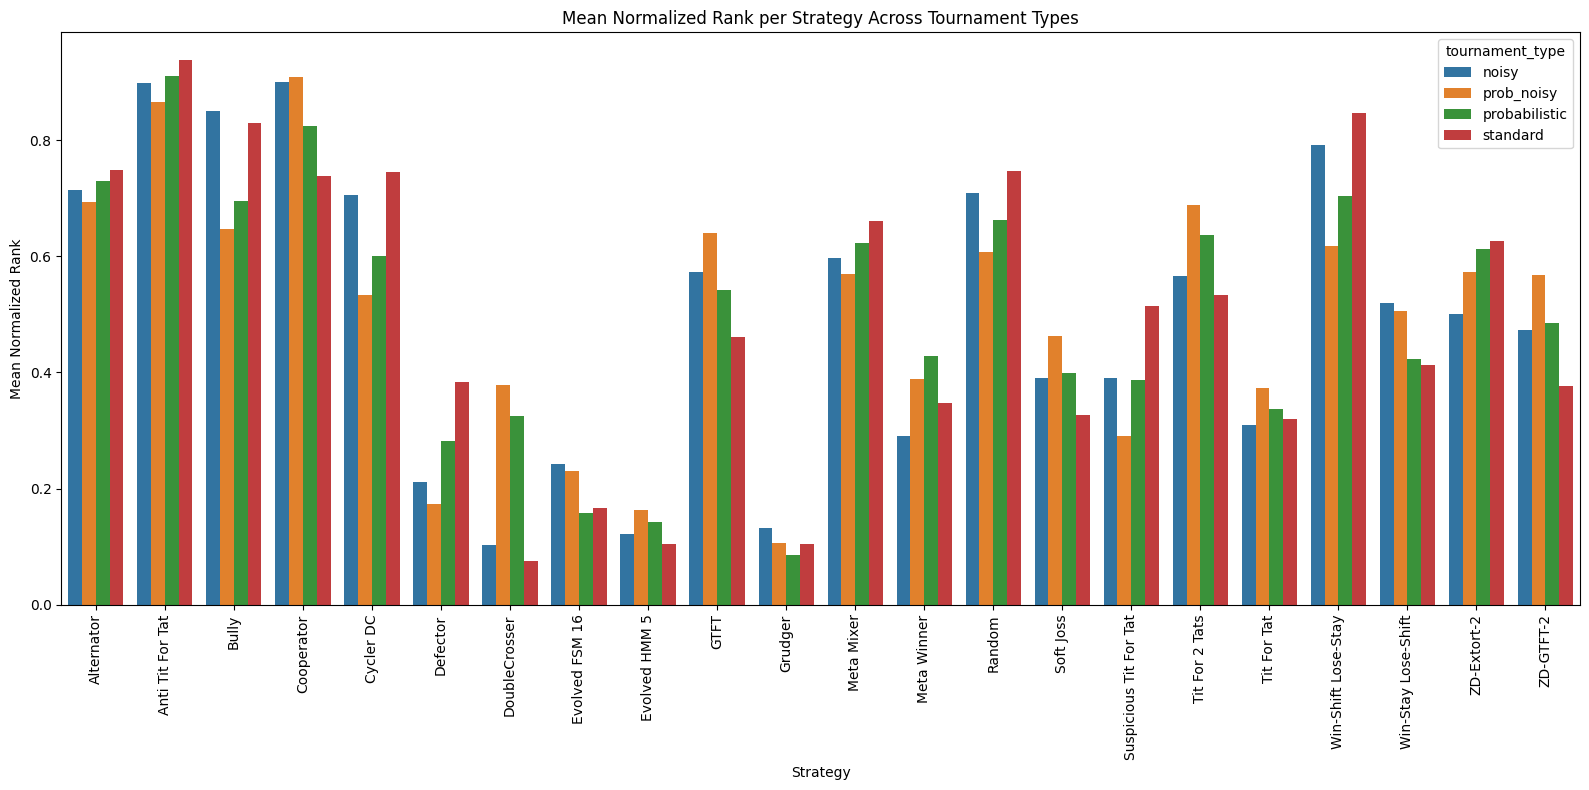

Saved plot: graphs/mean_score_comparison.png
Pairwise matchup matrix skipped: required columns (Name, Opponent, normalized_rank) not found.


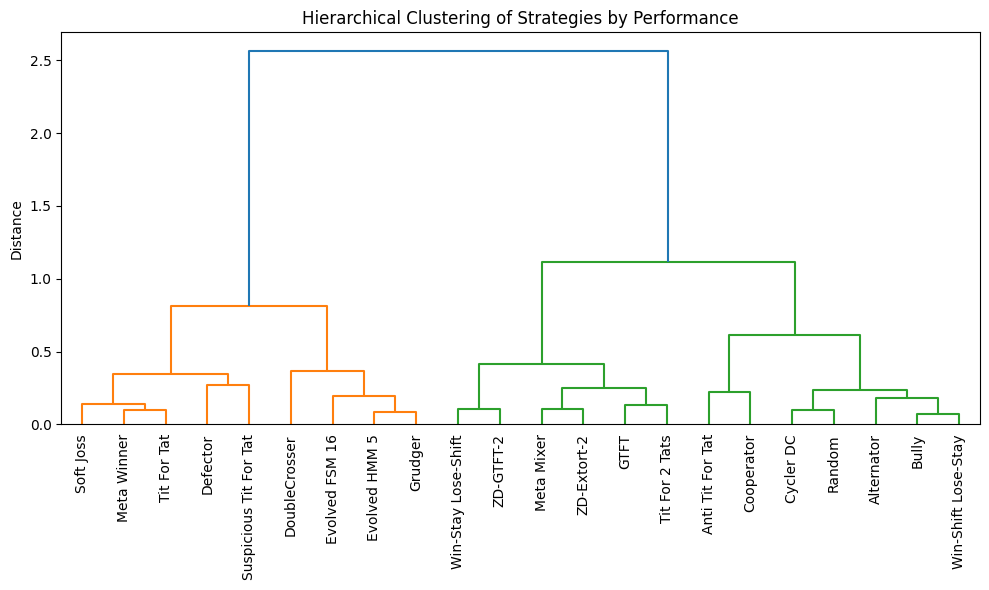

Saved plot: graphs/strategy_clustering_dendrogram.png


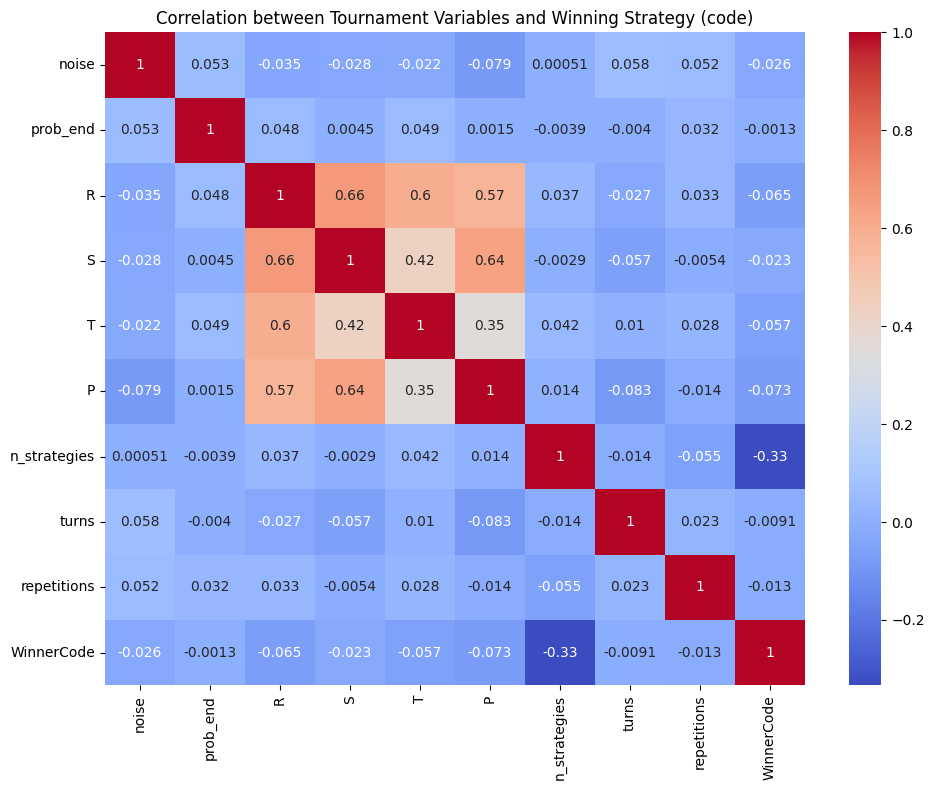

Saved plot: graphs/winner_variable_correlation_heatmap.png


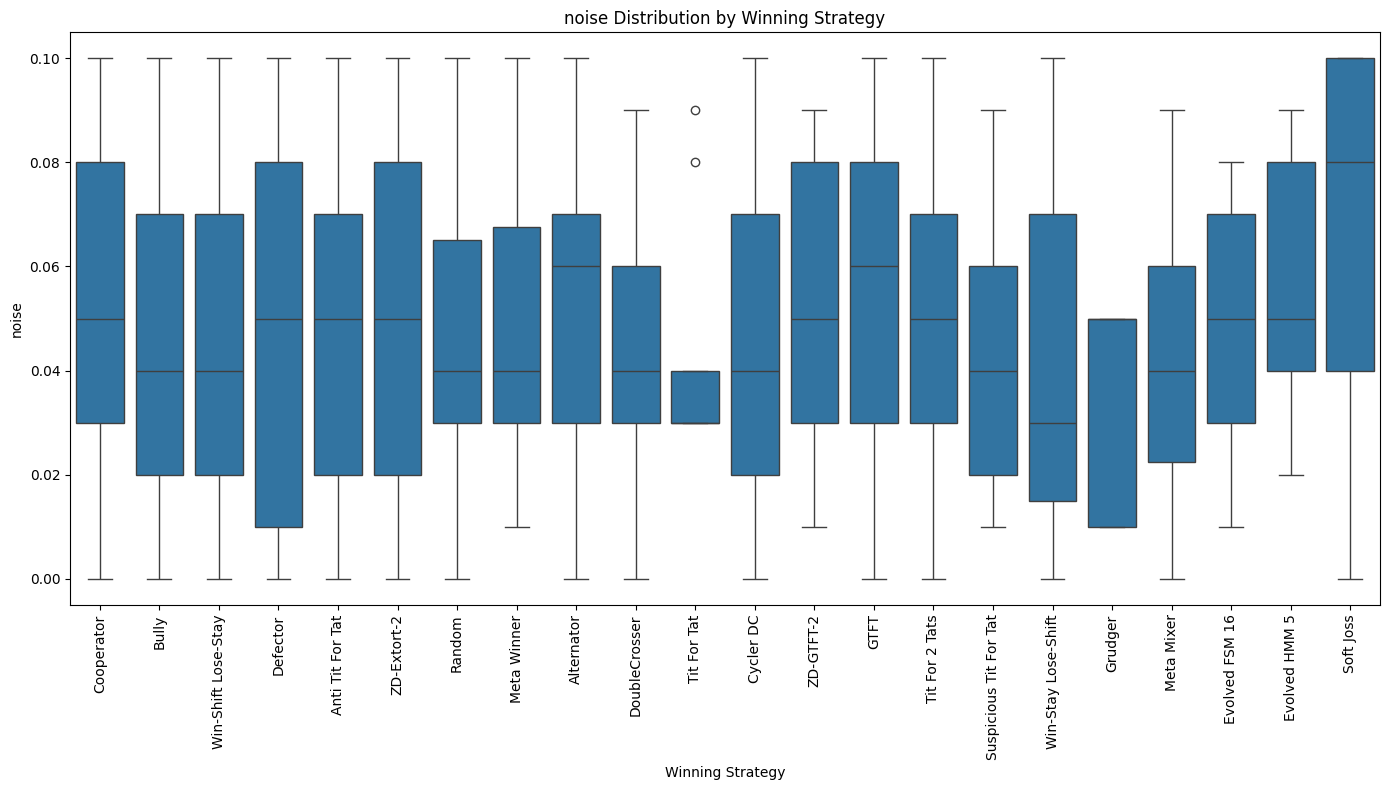

Saved plot: graphs/winner_noise_boxplot.png


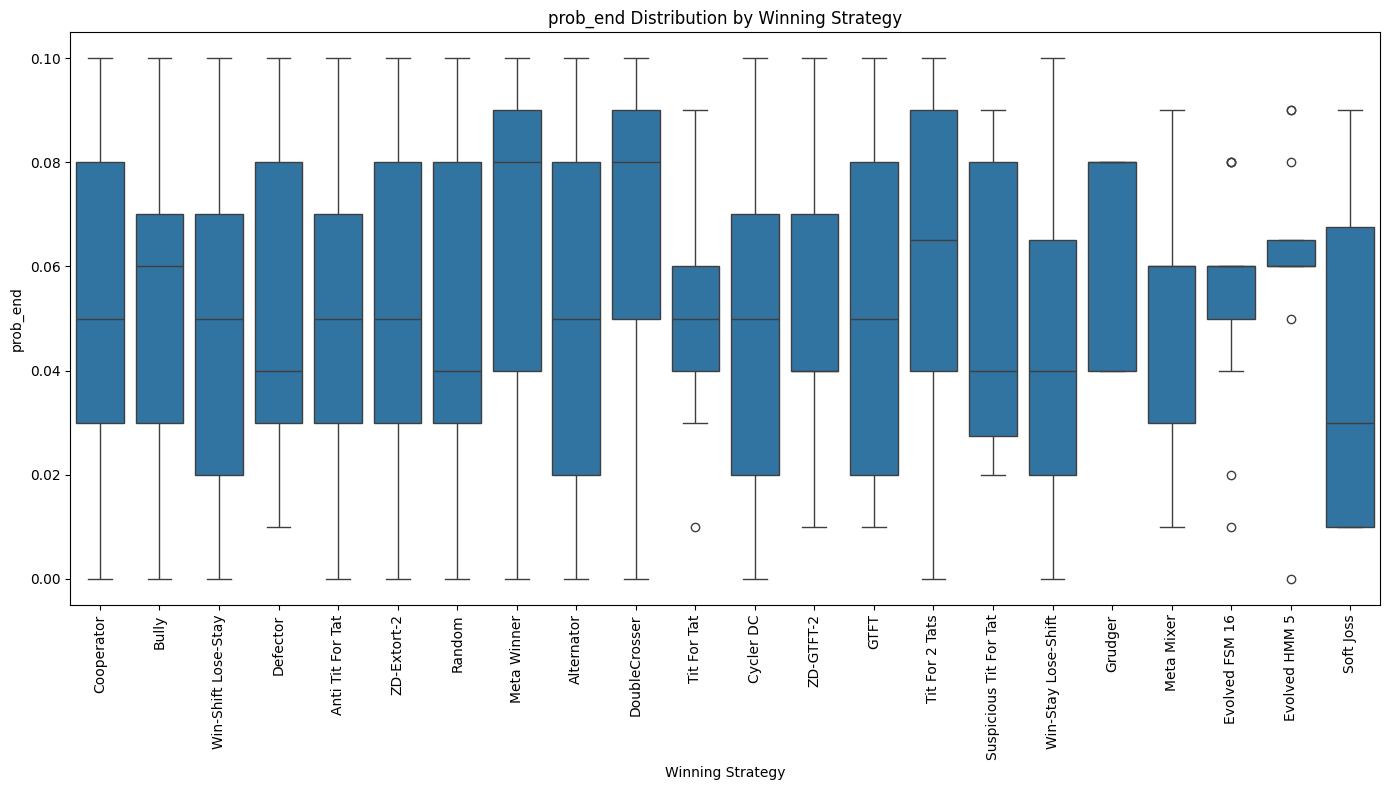

Saved plot: graphs/winner_prob_end_boxplot.png


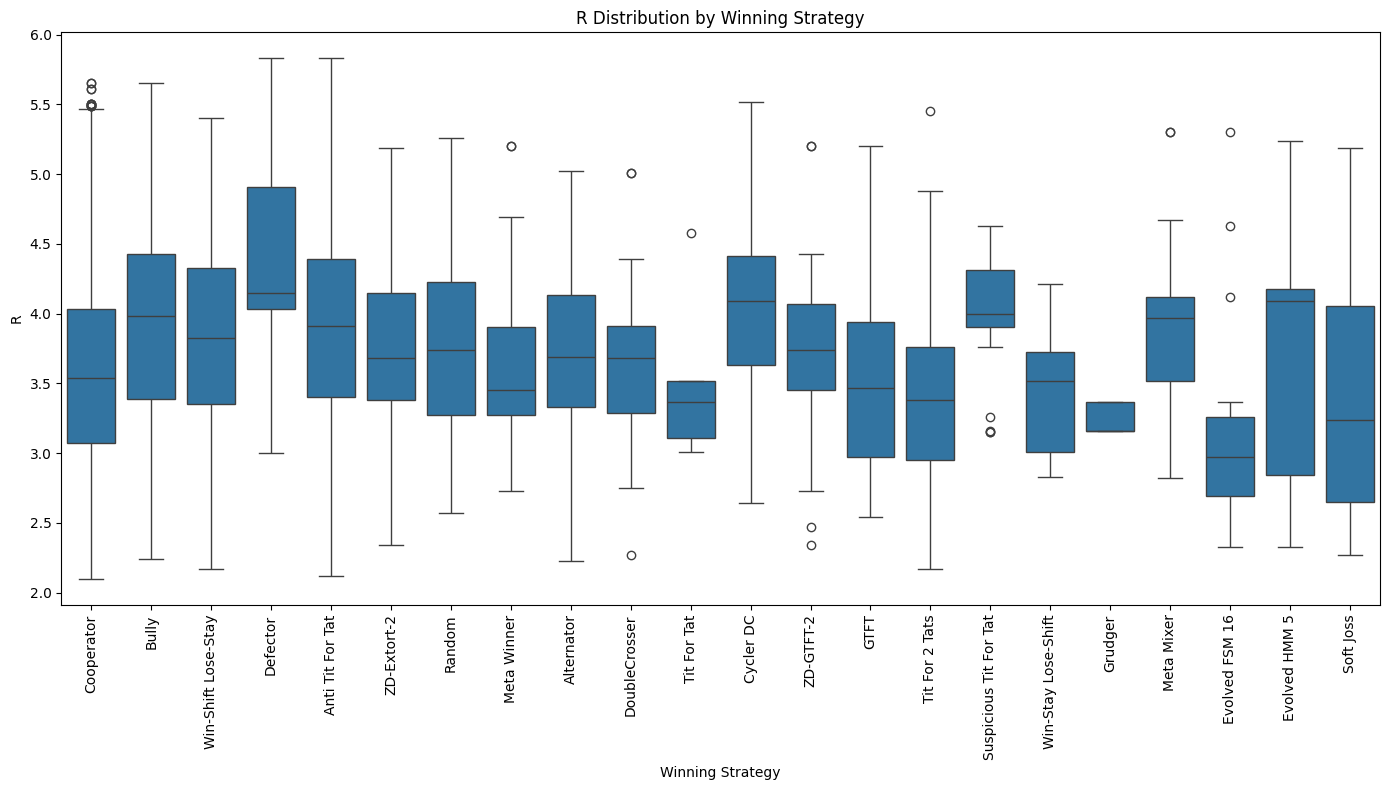

Saved plot: graphs/winner_R_boxplot.png


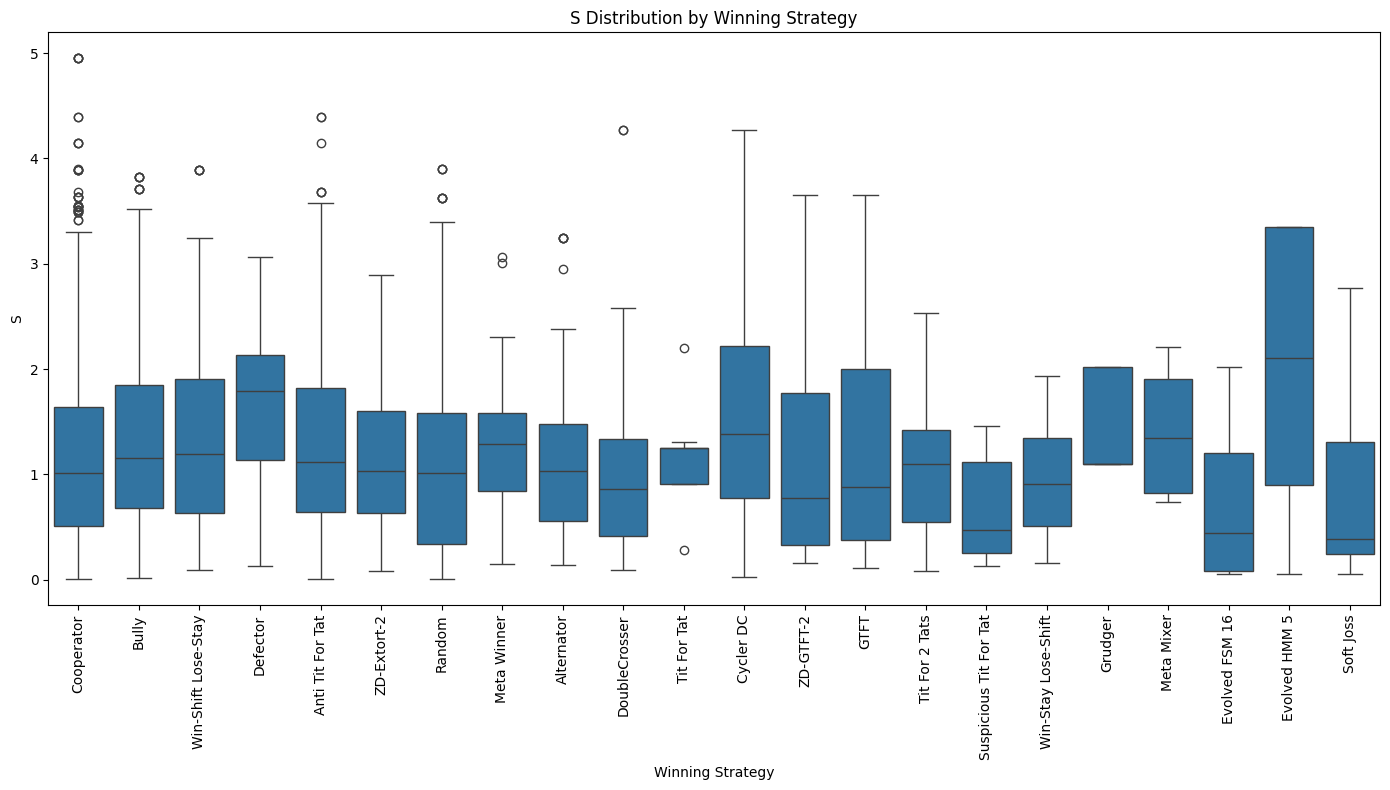

Saved plot: graphs/winner_S_boxplot.png


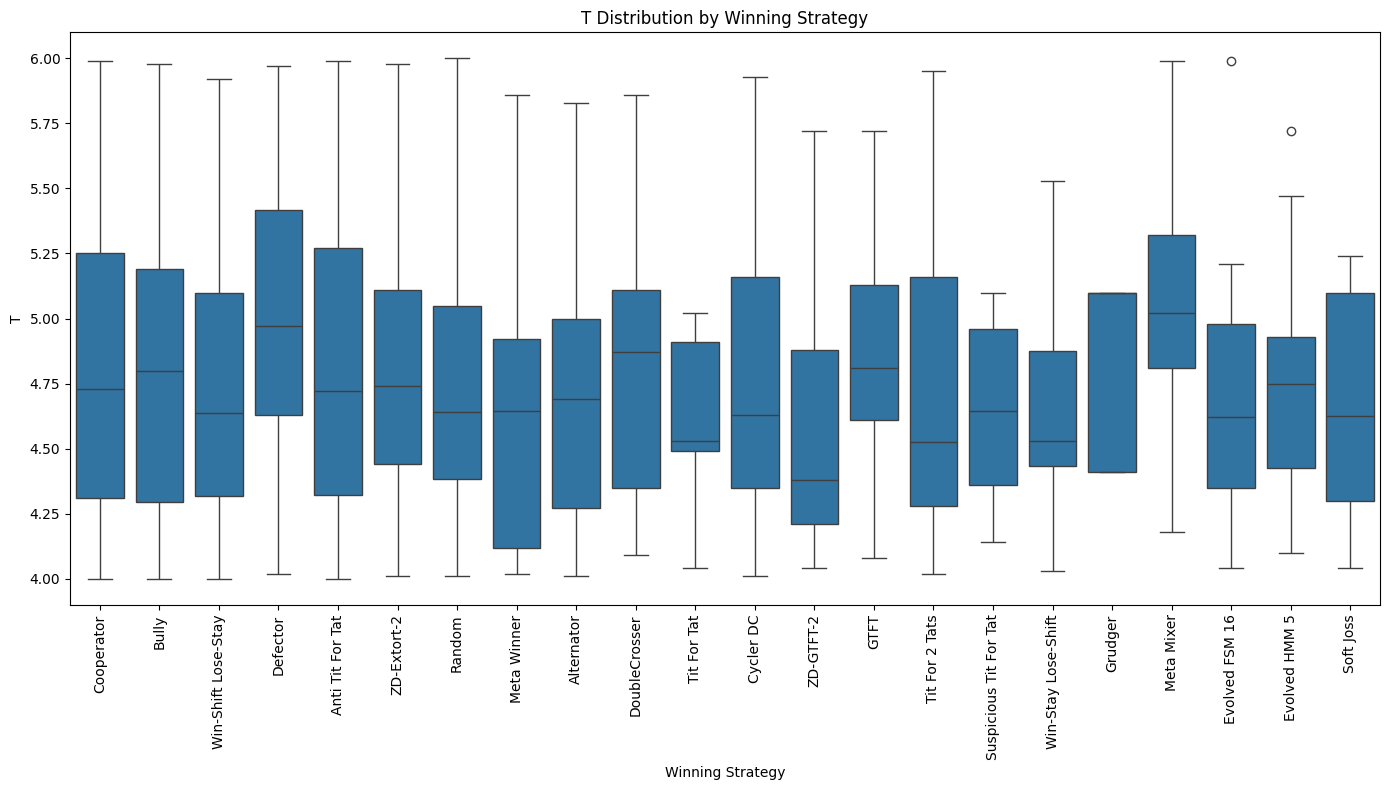

Saved plot: graphs/winner_T_boxplot.png


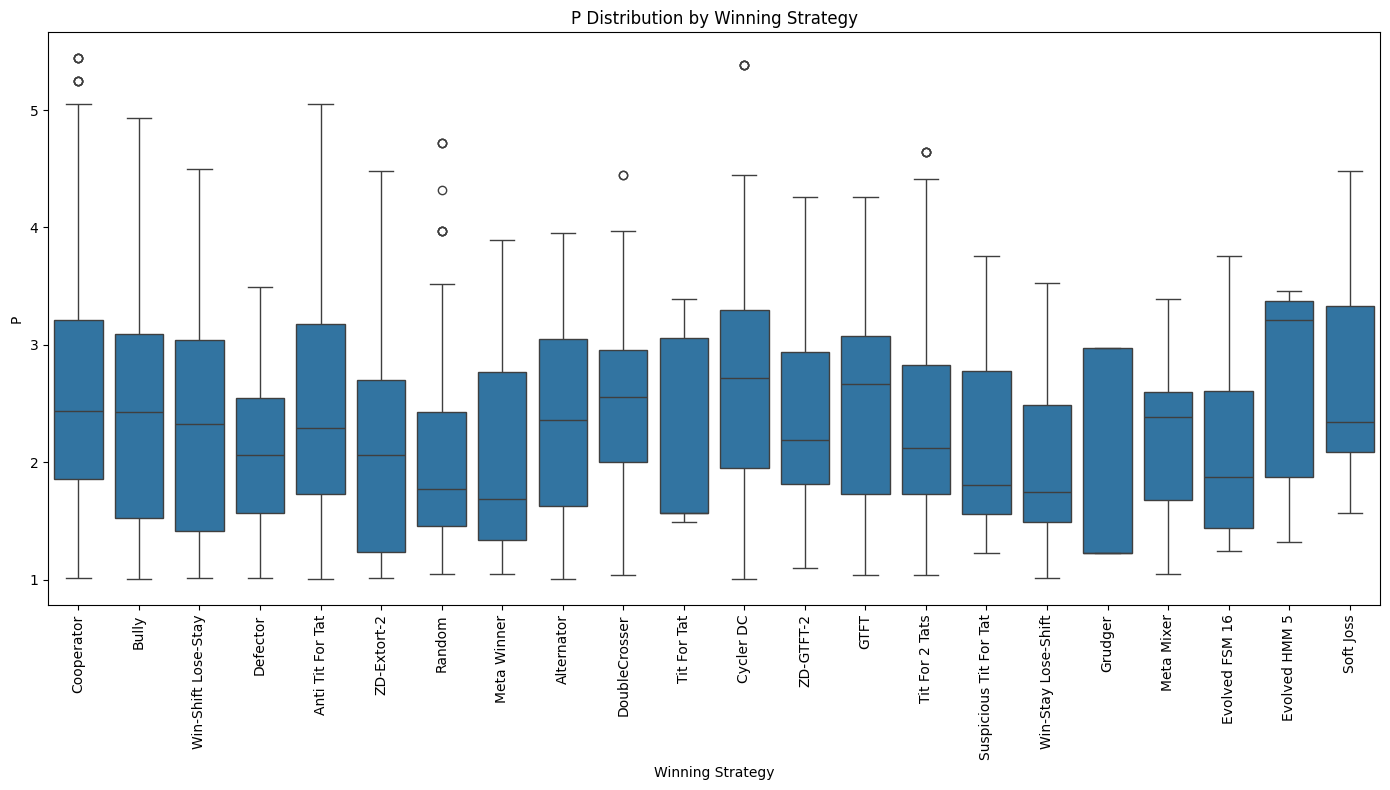

Saved plot: graphs/winner_P_boxplot.png


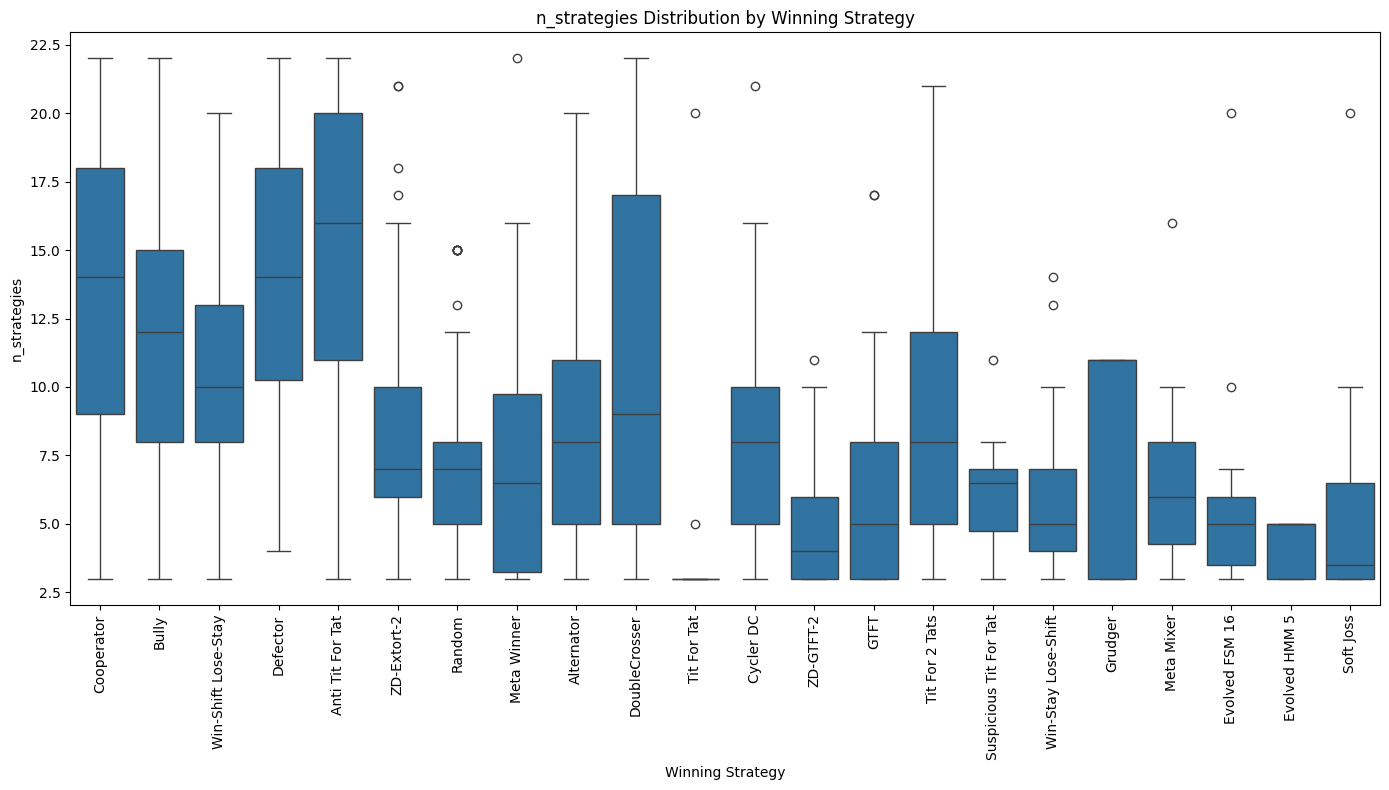

Saved plot: graphs/winner_n_strategies_boxplot.png


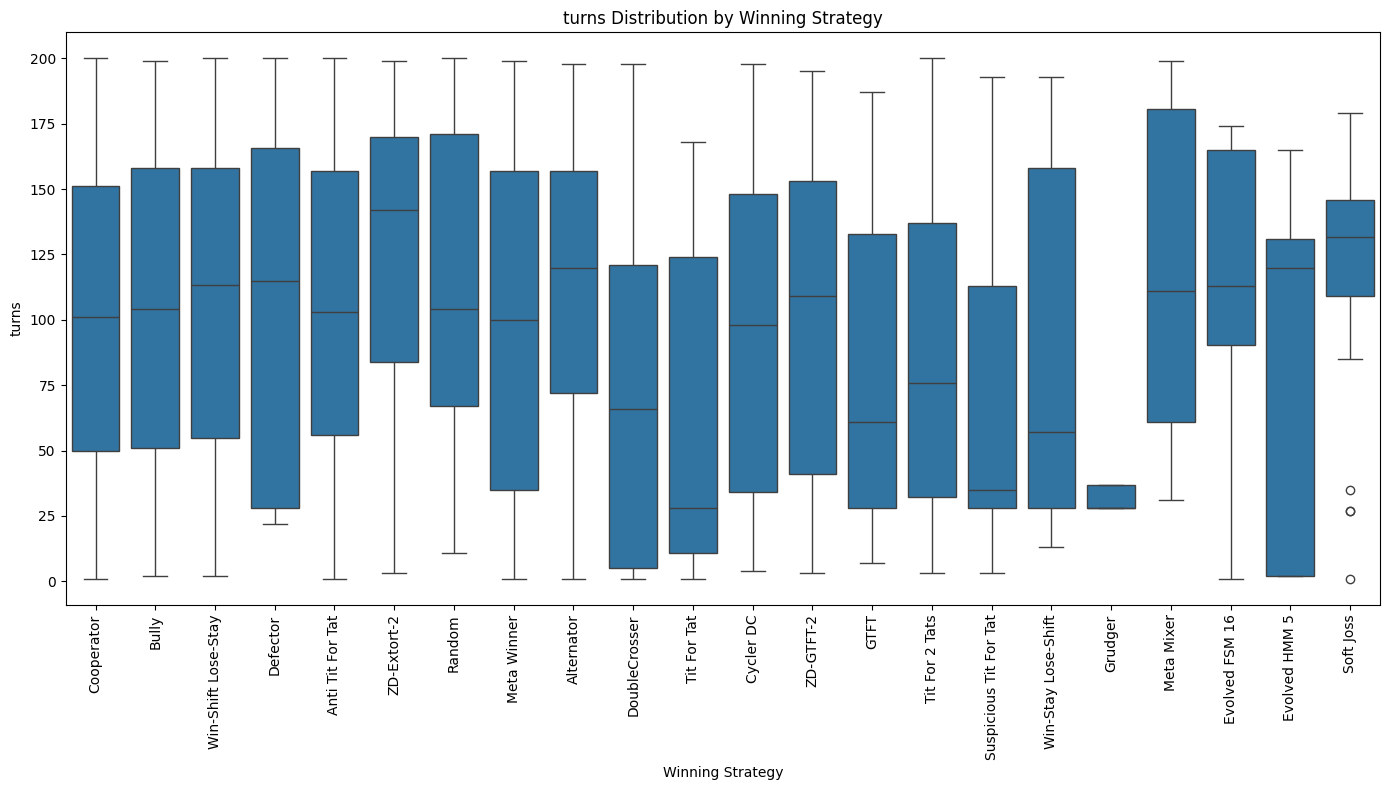

Saved plot: graphs/winner_turns_boxplot.png


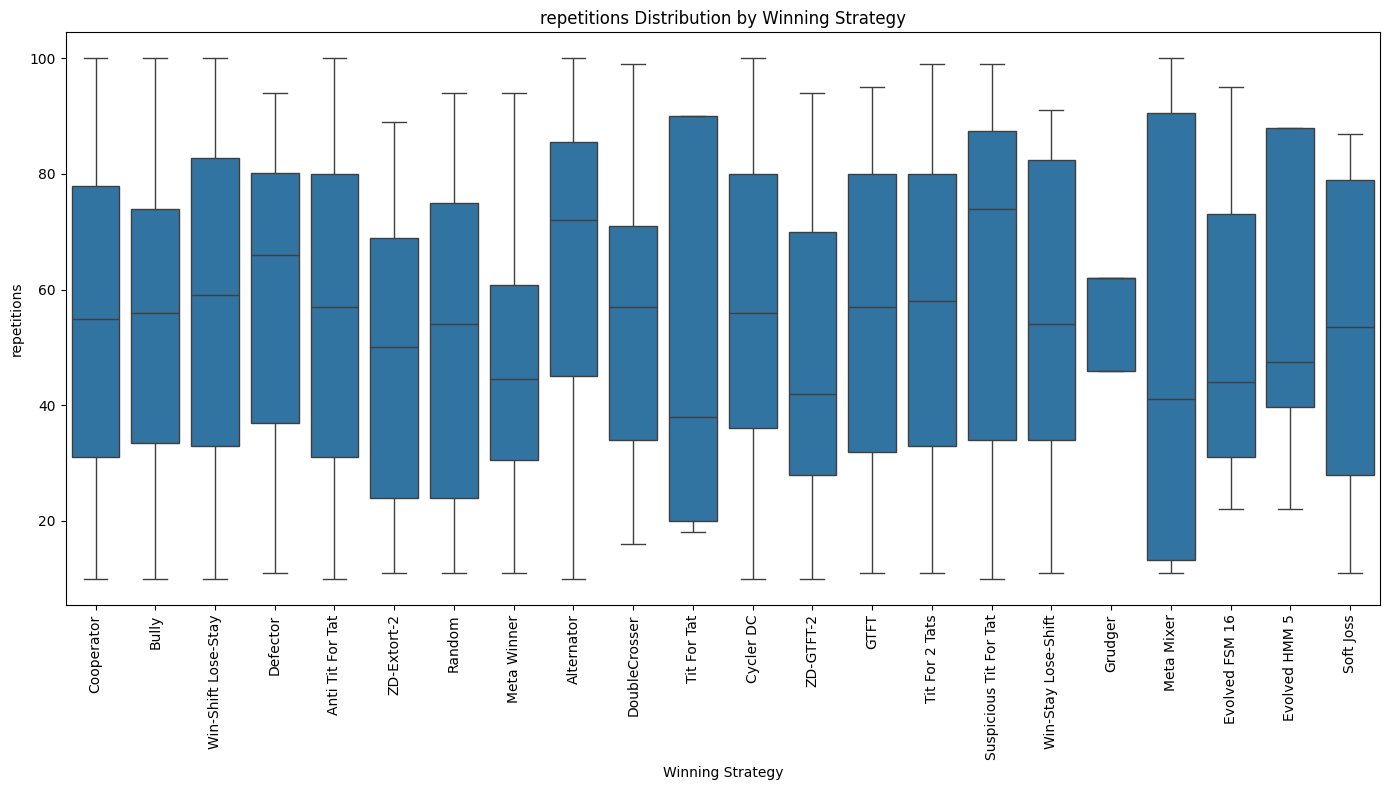

Saved plot: graphs/winner_repetitions_boxplot.png


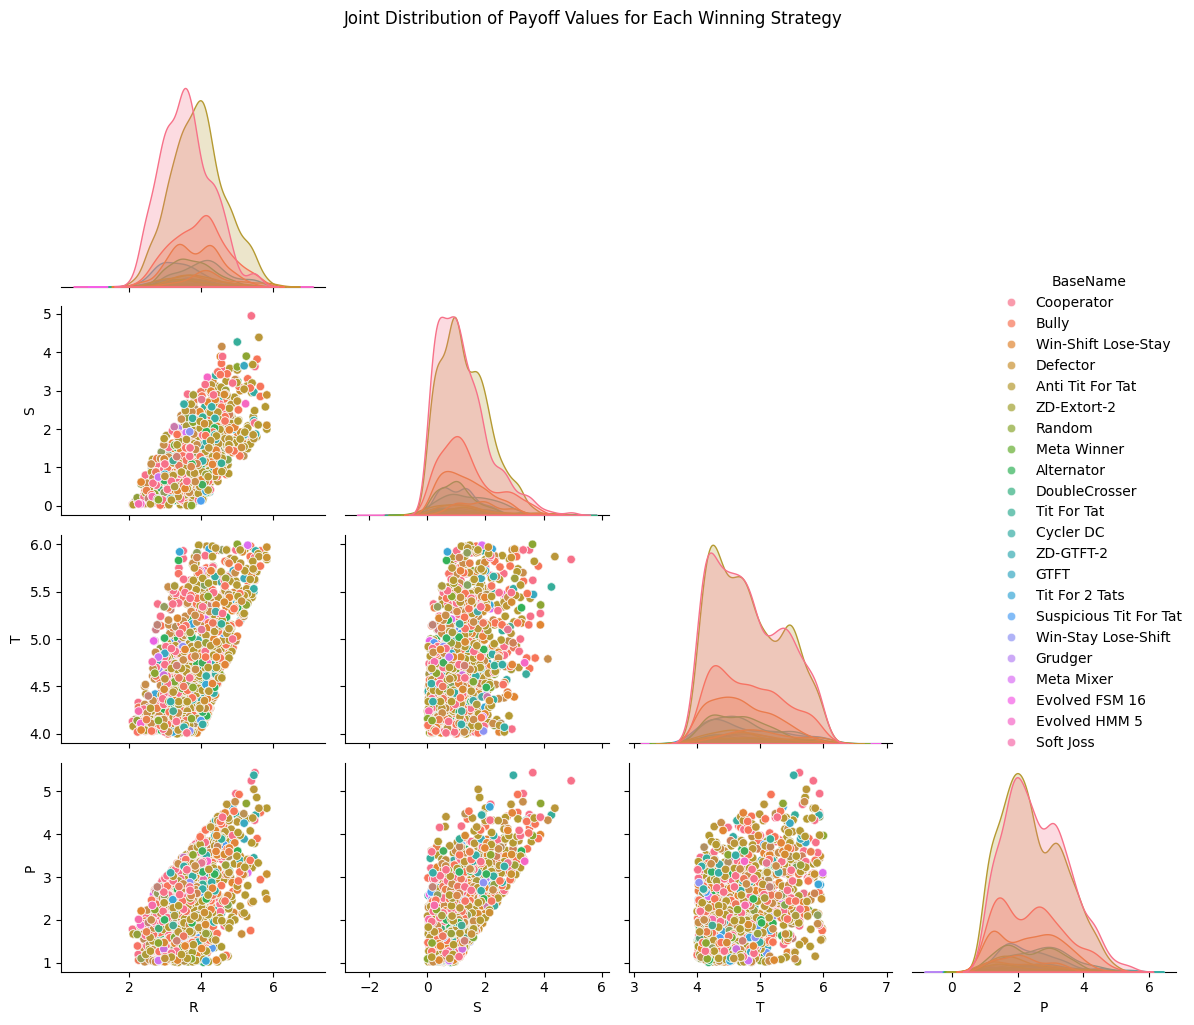

Saved plot: graphs/winner_payoff_pairplot.png


In [50]:
# Advanced analysis and comparison plots
if dfs:
    all_data = pd.concat(dfs, ignore_index=True)
    all_data['BaseName'] = all_data['Name'].apply(extract_base_name)
    # Boxplot: Score distribution per strategy per tournament type
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'tournament_type' in all_data.columns:
        plt.figure(figsize=(16, 8))
        # Group by BaseName and tournament_type, not by all columns
        sns.boxplot(data=all_data, x='BaseName', y='normalized_rank', hue='tournament_type')
        plt.title("Normalized Rank Distribution per Strategy Across Tournament Types")
        plt.ylabel("Normalized Rank")
        plt.xlabel("Strategy")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        plt.savefig("graphs/score_distribution_boxplot.png")
        plt.close()
        print("Saved plot: graphs/score_distribution_boxplot.png")
  
# Grouped barplot: Mean Normalized Rank per strategy per tournament type
        mean_scores = all_data.groupby(['BaseName', 'tournament_type'])['normalized_rank'].mean().reset_index()
        plt.figure(figsize=(16, 8))
        sns.barplot(data=mean_scores, x='BaseName', y='normalized_rank', hue='tournament_type')
        plt.title("Mean Normalized Rank per Strategy Across Tournament Types")
        plt.ylabel("Mean Normalized Rank")
        plt.xlabel("Strategy")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        plt.savefig("graphs/mean_score_comparison.png")
        plt.close()
        print("Saved plot: graphs/mean_score_comparison.png")
    else:
        print("Required columns not found for advanced plots")

        # Correlation heatmap of numeric variables
        numeric_cols = ['normalized_rank', 'Cooperation_rating', 'noise', 'prob_end', 'repetitions', 'turns', 'n_strategies']
        corr = all_data[numeric_cols].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap='coolwarm')
        plt.title('Correlation Matrix of Tournament Variables')
        plt.tight_layout()
        plt.show()
        plt.savefig('graphs/correlation_heatmap.png')
        plt.close()
        print('Saved plot: graphs/correlation_heatmap.png')

        # Scatter plot: Normalized Rank vs. Noise by Strategy (use BaseName)
        plt.figure(figsize=(14, 8))
        sns.scatterplot(data=all_data, x='noise', y='normalized_rank', hue='BaseName', alpha=0.7)
        plt.title('Normalized Rank vs. Noise by Strategy')
        plt.ylabel('Normalized Rank')
        plt.xlabel('Noise')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        plt.savefig('graphs/score_vs_noise.png')
        plt.close()
        print('Saved plot: graphs/score_vs_noise.png')

        # Barplot: Number of wins (highest Normalized Rank) per strategy (use BaseName)
        win_counts = all_data.loc[all_data.groupby(['tournament_type', 'Rank'])['normalized_rank'].idxmax()]
        win_counts['BaseName'] = win_counts['Name'].apply(extract_base_name)
        win_summary = win_counts['BaseName'].value_counts().sort_values(ascending=False)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=win_summary.index, y=win_summary.values)
        plt.title('Number of Tournament Wins per Strategy (Highest Normalized Rank)')
        plt.ylabel('Number of Wins')
        plt.xlabel('Strategy')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        plt.savefig('graphs/strategy_win_counts.png')
        plt.close()
        print('Saved plot: graphs/strategy_win_counts.png')

        # Scatter plot: Cooperation vs. Normalized Rank (use BaseName)
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=all_data, x='Cooperation_rating', y='normalized_rank', hue='BaseName', alpha=0.7)
        plt.title('Cooperation Rating vs. Normalized Rank by Strategy')
        plt.xlabel('Cooperation Rating')
        plt.ylabel('Normalized Rank')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        plt.savefig('graphs/cooperation_vs_score.png')
        plt.close()
        print('Saved plot: graphs/cooperation_vs_score.png')

        # Parameter sensitivity: Score vs. n_strategies (use BaseName)
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=all_data, x='n_strategies', y='normalized_rank', hue='BaseName', alpha=0.7)
        plt.title('Normalized Rank vs. Number of Strategies in Tournament')
        plt.xlabel('Number of Strategies')
        plt.ylabel('Normalized Rank')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        plt.savefig('graphs/score_vs_n_strategies.png')
        plt.close()
        print('Saved plot: graphs/score_vs_n_strategies.png')

        # Robustness: Boxplot of Normalized Rank Std Dev per Strategy (use BaseName)
        score_std = all_data.groupby('BaseName')['normalized_rank'].std().sort_values(ascending=False)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=score_std.index, y=score_std.values)
        plt.title('Score Standard Deviation per Strategy (Robustness)')
        plt.ylabel('Std Dev of Normalized Rank')
        plt.xlabel('Strategy')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        plt.savefig('graphs/score_std_per_strategy.png')
        plt.close()
        print('Saved plot: graphs/score_std_per_strategy.png')

        # Cooperation vs. Score by Tournament Type (FacetGrid, use BaseName)
        g = sns.FacetGrid(all_data, col='tournament_type', col_wrap=2, height=5, sharex=True, sharey=True)
        g.map_dataframe(sns.scatterplot, x='Cooperation_rating', y='normalized_rank', hue='BaseName', alpha=0.7)
        g.add_legend()
        g.set_axis_labels('Cooperation Rating', 'Normalized Rank')
        g.fig.suptitle('Cooperation vs. Normalized Rank by Tournament Type', y=1.02)
        plt.tight_layout()
        plt.show()
        g.savefig('graphs/cooperation_vs_score_facet.png')
        plt.close()
        print('Saved plot: graphs/cooperation_vs_score_facet.png')

        # --- Advanced: Pairwise Matchup Matrix (Heatmap) ---
    if 'Name' in all_data.columns and 'Opponent' in all_data.columns and 'normalized_rank' in all_data.columns:
        # Pivot to get average score for each (strategy, opponent) pair
        matchup = all_data.pivot_table(index='Name', columns='Opponent', values='normalized_rank', aggfunc='mean')
        plt.figure(figsize=(14, 12))
        sns.heatmap(matchup, annot=False, cmap='viridis')
        plt.title('Pairwise Matchup: Average Normalized Rank (Strategy vs. Opponent)')
        plt.ylabel('Strategy')
        plt.xlabel('Opponent')
        plt.tight_layout()
        plt.show()
        plt.savefig('graphs/pairwise_matchup_heatmap.png')
        plt.close()
        print('Saved plot: graphs/pairwise_matchup_heatmap.png')
    else:
        print('Pairwise matchup matrix skipped: required columns (Name, Opponent, normalized_rank) not found.')

    # --- Advanced: Clustering of Strategies (Hierarchical) ---
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'tournament_type' in all_data.columns:
        # Create a matrix: rows=base strategies, columns=tournament types, values=mean Normalized Rank
        perf_matrix = all_data.pivot_table(index='BaseName', columns='tournament_type', values='normalized_rank', aggfunc='mean').fillna(0)
        from scipy.cluster.hierarchy import linkage, dendrogram
        import numpy as np
        plt.figure(figsize=(10, 6))
        linkage_matrix = linkage(perf_matrix, method='ward')
        dendrogram(linkage_matrix, labels=perf_matrix.index, leaf_rotation=90)
        plt.title('Hierarchical Clustering of Strategies by Performance')
        plt.ylabel('Distance')
        plt.tight_layout()
        plt.show()
        plt.savefig('graphs/strategy_clustering_dendrogram.png')
        plt.close()
        print('Saved plot: graphs/strategy_clustering_dendrogram.png')
    else:
        print('Strategy clustering skipped: required columns not found.')

        # --- Correlation between tournament variables and winning strategies ---
    # For each run and tournament type, find the winning strategy (highest mean Normalized Rank)
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'run' in all_data.columns and 'tournament_type' in all_data.columns:
        # Find the winner for each run and tournament type
        winners = all_data.loc[all_data.groupby(['run', 'tournament_type'])['normalized_rank'].idxmax()]
        # Select relevant columns for correlation
        corr_vars = ['noise', 'prob_end', 'R', 'S', 'T', 'P', 'n_strategies', 'turns', 'repetitions']
        # Encode winning strategy as categorical codes for correlation
        winners = winners.copy()
        winners['WinnerCode'] = winners['BaseName'].astype('category').cat.codes
        # Compute correlation matrix
        corr = winners[corr_vars + ['WinnerCode']].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap='coolwarm')
        plt.title('Correlation between Tournament Variables and Winning Strategy (code)')
        plt.tight_layout()
        plt.show()
        plt.savefig('graphs/winner_variable_correlation_heatmap.png')
        plt.close()
        print('Saved plot: graphs/winner_variable_correlation_heatmap.png')
    else:
        print('Could not compute winner-variable correlation: required columns not found.')

    # --- Boxplots: Each variable vs. Winning Strategy ---
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'run' in all_data.columns and 'tournament_type' in all_data.columns:
        winners = all_data.loc[all_data.groupby(['run', 'tournament_type'])['normalized_rank'].idxmax()]
        corr_vars = ['noise', 'prob_end', 'R', 'S', 'T', 'P', 'n_strategies', 'turns', 'repetitions']
        for var in corr_vars:
            if var in winners.columns:
                plt.figure(figsize=(14, 8))
                sns.boxplot(data=winners, x='BaseName', y=var)
                plt.title(f'{var} Distribution by Winning Strategy')
                plt.xlabel('Winning Strategy')
                plt.ylabel(var)
                plt.xticks(rotation=90)
                plt.tight_layout()
                plt.show()
                plt.savefig(f'graphs/winner_{var}_boxplot.png')
                plt.close()
                print(f'Saved plot: graphs/winner_{var}_boxplot.png')
    else:
        print('Could not create variable-vs-winner boxplots: required columns not found.')

    # --- Pairplot: Joint distribution of payoffs for each winning strategy ---
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'run' in all_data.columns and 'tournament_type' in all_data.columns:
        winners = all_data.loc[all_data.groupby(['run', 'tournament_type'])['normalized_rank'].idxmax()]
        payoff_vars = ['R', 'S', 'T', 'P']
        if all(var in winners.columns for var in payoff_vars):
            import seaborn as sns
            sns.pairplot(winners, vars=payoff_vars, hue='BaseName', corner=True, plot_kws={'alpha':0.7})
            plt.suptitle('Joint Distribution of Payoff Values for Each Winning Strategy', y=1.02)
            plt.tight_layout()
            plt.show()
            plt.savefig('graphs/winner_payoff_pairplot.png')
            plt.close()
            print('Saved plot: graphs/winner_payoff_pairplot.png')
        else:
            print('Could not create payoff pairplot: some payoff columns missing.')
    else:
        print('Could not create payoff pairplot: required columns not found.')
